# **Multimodal Function Optimization using Genetic Algorithms**

An evolutionary computation project focusing on function optimization, diversity maintenance (Fitness Sharing), and restricted mating (Speciation).

---

### **Context & Problem Description**

The objective is to find the global maximum $(x^*, y^*)$ of the following continuous, highly multimodal 2D function:

$$f(x, y) = x \sin(4\pi x) - y \sin(4\pi y + \pi) + 1$$

where $x, y \in [-1, 2]$. 

Due to the presence of multiple local optima, standard Genetic Algorithms might suffer from premature convergence. This project explores techniques like **Fitness Sharing** and **Restricted Mating** to maintain population diversity and successfully locate the global maximum.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from matplotlib import cm

import warnings
warnings.filterwarnings('ignore')


### **Objective Function Visualization**

We first define the objective function and visualize its surface and contour plots to understand the landscape we are optimizing.


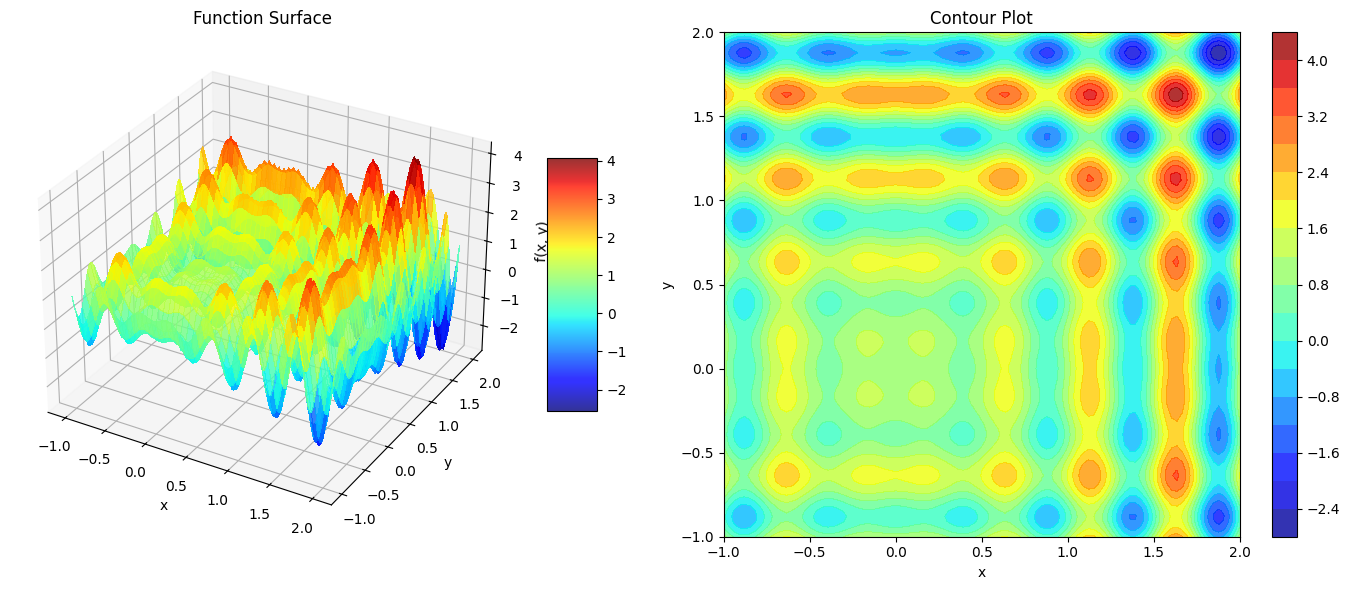

In [2]:
def objective_function(x, y):
    return x * np.sin(4 * np.pi * x) - y * np.sin(4 * np.pi * y + np.pi) + 1

# Generate meshgrid for plotting
X = np.linspace(-1, 2, 100)
Y = np.linspace(-1, 2, 100)
X, Y = np.meshgrid(X, Y)
Z = objective_function(X, Y)

fig = plt.figure(figsize=(14, 6))

# Surface Plot
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap=cm.jet, linewidth=0, antialiased=False, alpha=0.8)
ax1.set_title('Function Surface')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x, y)')
fig.colorbar(surf, shrink=0.5, aspect=5)

# Contour Plot
ax2 = fig.add_subplot(122)
contour = ax2.contourf(X, Y, Z, 20, cmap=cm.jet, alpha=0.8)
ax2.set_title('Contour Plot')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
fig.colorbar(contour)

plt.tight_layout()
plt.show()


## **Standard Genetic Algorithm Implementation**

**Representation**: Real-valued encoding. Each individual is represented as a list `[x, y]`.
**Fitness Function**: Directly the objective function value, shifted to be strictly positive if necessary (though here the max is > 0).
**Selection**: Tournament selection.
**Crossover**: Simulated Binary Crossover (SBX).
**Mutation**: Polynomial Mutation.


In [3]:
def get_random_individual():
    return [np.random.uniform(-1, 2), np.random.uniform(-1, 2)]

def evaluate_fitness(ind):
    return objective_function(ind[0], ind[1])

def tournament_selection(population, fitness, k=3):
    selected_indices = random.sample(range(len(population)), k)
    best_idx = selected_indices[np.argmax([fitness[i] for i in selected_indices])]
    return population[best_idx]

def simulated_binary_crossover(p1, p2, nc=20):
    c1, c2 = [0.0, 0.0], [0.0, 0.0]
    for i in range(2):
        u = np.random.rand()
        beta = (2 * u)**(1 / (nc + 1)) if u <= 0.5 else (1 / (2 * (1 - u)))**(1 / (nc + 1))
        c1[i] = 0.5 * ((1 + beta) * p1[i] + (1 - beta) * p2[i])
        c2[i] = 0.5 * ((1 - beta) * p1[i] + (1 + beta) * p2[i])
        # Enforce bounds
        c1[i] = np.clip(c1[i], -1, 2)
        c2[i] = np.clip(c2[i], -1, 2)
    return c1, c2

def polynomial_mutation(ind, nm=20, pm=0.1):
    mutated = list(ind)
    for i in range(2):
        if np.random.rand() < pm:
            r = np.random.rand()
            delta = (2 * r)**(1 / (nm + 1)) - 1 if r < 0.5 else 1 - (2 * (1 - r))**(1 / (nm + 1))
            mutated[i] += delta * (2 - (-1)) # multiply by range
            mutated[i] = np.clip(mutated[i], -1, 2)
    return mutated


In [4]:
def run_standard_ga(n_pop=100, n_gen=50, pc=0.9, pm=0.1):
    population = [get_random_individual() for _ in range(n_pop)]
    
    best_fitness_history = []
    avg_fitness_history = []
    
    for gen in range(n_gen):
        fitness = [evaluate_fitness(ind) for ind in population]
        
        best_fitness_history.append(np.max(fitness))
        avg_fitness_history.append(np.mean(fitness))
        
        new_population = []
        # Elitism
        best_idx = np.argmax(fitness)
        new_population.append(population[best_idx])
        
        while len(new_population) < n_pop:
            p1 = tournament_selection(population, fitness)
            p2 = tournament_selection(population, fitness)
            
            if np.random.rand() < pc:
                c1, c2 = simulated_binary_crossover(p1, p2)
            else:
                c1, c2 = p1, p2
                
            c1 = polynomial_mutation(c1, pm=pm)
            c2 = polynomial_mutation(c2, pm=pm)
            
            new_population.extend([c1, c2])
            
        population = new_population[:n_pop]
        
    final_fitness = [evaluate_fitness(ind) for ind in population]
    best_overall_idx = np.argmax(final_fitness)
    
    return population, best_fitness_history, avg_fitness_history, population[best_overall_idx], final_fitness[best_overall_idx]

# Run it once
final_pop, best_fit, avg_fit, best_ind, best_val = run_standard_ga()

print(f"Standard GA - Best found: x={best_ind[0]:.4f}, y={best_ind[1]:.4f} | f(x,y) = {best_val:.4f}")


Standard GA - Best found: x=1.6289, y=1.6288 | f(x,y) = 4.2539


## **Fitness Sharing**

To prevent the entire population from converging to a single local maximum (premature convergence), **Fitness Sharing** reduces the fitness of individuals that are clustered closely together. This promotes the exploration of multiple peaks simultaneously.

The shared fitness $f_{share}(i)$ is calculated as:
$$f_{share}(i) = \frac{f(i)}{\sum_{j=1}^{N} sh(d(i,j))}$$

where $sh(d)$ is the sharing function based on the Euclidean distance $d$ and a sharing radius $\sigma_{share}$.


In [5]:
def sharing_function(d, sigma_share=0.1, alpha=1.0):
    if d < sigma_share:
        return 1.0 - (d / sigma_share) ** alpha
    return 0.0

def calculate_shared_fitness(population, raw_fitness, sigma_share=0.1):
    shared_fitness = []
    # Ensure fitness is strictly positive for sharing
    min_fit = min(raw_fitness)
    if min_fit < 0:
        adjusted_fitness = [f - min_fit + 1e-5 for f in raw_fitness]
    else:
        adjusted_fitness = raw_fitness
        
    for i in range(len(population)):
        m_i = 0
        for j in range(len(population)):
            d = np.sqrt((population[i][0] - population[j][0])**2 + (population[i][1] - population[j][1])**2)
            m_i += sharing_function(d, sigma_share)
        shared_fitness.append(adjusted_fitness[i] / m_i)
        
    return shared_fitness

def run_sharing_ga(n_pop=100, n_gen=50, pc=0.9, pm=0.1, sigma_share=0.1):
    population = [get_random_individual() for _ in range(n_pop)]
    
    best_fitness_history = []
    avg_fitness_history = []
    
    for gen in range(n_gen):
        raw_fitness = [evaluate_fitness(ind) for ind in population]
        shared_fitness = calculate_shared_fitness(population, raw_fitness, sigma_share)
        
        best_fitness_history.append(np.max(raw_fitness))
        avg_fitness_history.append(np.mean(raw_fitness))
        
        new_population = []
        # Elitism (using raw fitness)
        best_idx = np.argmax(raw_fitness)
        new_population.append(population[best_idx])
        
        while len(new_population) < n_pop:
            p1 = tournament_selection(population, shared_fitness)
            p2 = tournament_selection(population, shared_fitness)
            
            if np.random.rand() < pc:
                c1, c2 = simulated_binary_crossover(p1, p2)
            else:
                c1, c2 = p1, p2
                
            c1 = polynomial_mutation(c1, pm=pm)
            c2 = polynomial_mutation(c2, pm=pm)
            
            new_population.extend([c1, c2])
            
        population = new_population[:n_pop]
        
    final_fitness = [evaluate_fitness(ind) for ind in population]
    best_overall_idx = np.argmax(final_fitness)
    
    return population, best_fitness_history, avg_fitness_history, population[best_overall_idx], final_fitness[best_overall_idx]


## **Restricted Mating (Speciation)**

To further enhance speciation, we restrict mating (crossover) to individuals that are within a certain distance $\sigma_{mate}$ of each other. This prevents the creation of "lethal" offspring that fall in the valleys between two peaks.


In [6]:
def run_speciated_ga(n_pop=100, n_gen=50, pc=0.9, pm=0.1, sigma_share=0.1, sigma_mate=0.1):
    population = [get_random_individual() for _ in range(n_pop)]
    
    best_fitness_history = []
    avg_fitness_history = []
    
    for gen in range(n_gen):
        raw_fitness = [evaluate_fitness(ind) for ind in population]
        shared_fitness = calculate_shared_fitness(population, raw_fitness, sigma_share)
        
        best_fitness_history.append(np.max(raw_fitness))
        avg_fitness_history.append(np.mean(raw_fitness))
        
        new_population = []
        # Elitism
        best_idx = np.argmax(raw_fitness)
        new_population.append(population[best_idx])
        
        while len(new_population) < n_pop:
            p1 = tournament_selection(population, shared_fitness)
            
            # Restricted mating logic
            p2 = None
            attempts = 0
            while attempts < 10: # try to find a mate nearby
                candidate = tournament_selection(population, shared_fitness)
                d = np.sqrt((p1[0] - candidate[0])**2 + (p1[1] - candidate[1])**2)
                if d < sigma_mate:
                    p2 = candidate
                    break
                attempts += 1
                
            if p2 is None: # fallback
                p2 = tournament_selection(population, shared_fitness)
                
            if np.random.rand() < pc:
                c1, c2 = simulated_binary_crossover(p1, p2)
            else:
                c1, c2 = p1, p2
                
            c1 = polynomial_mutation(c1, pm=pm)
            c2 = polynomial_mutation(c2, pm=pm)
            
            new_population.extend([c1, c2])
            
        population = new_population[:n_pop]
        
    final_fitness = [evaluate_fitness(ind) for ind in population]
    best_overall_idx = np.argmax(final_fitness)
    
    return population, best_fitness_history, avg_fitness_history, population[best_overall_idx], final_fitness[best_overall_idx]


## **Comparison and Visualizing Population Distribution**

We run the three variants (Standard GA, Fitness Sharing, and Fitness Sharing + Restricted Mating) and plot the final population on top of the function contour.


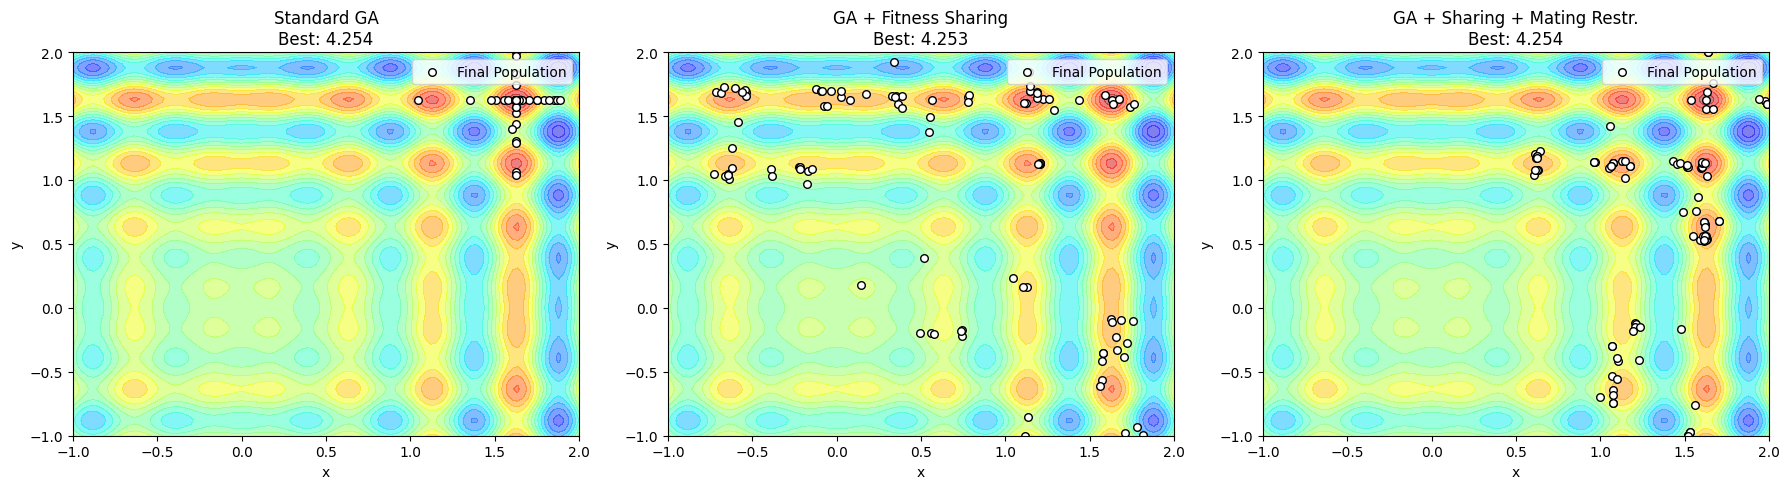

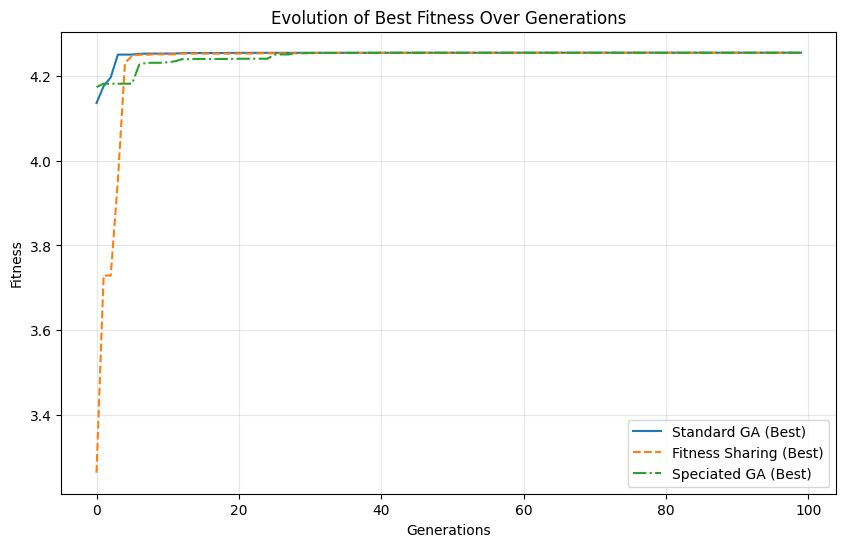

In [7]:
pop_std, b_std, a_std, best_i_std, best_v_std = run_standard_ga(n_gen=100)
pop_shr, b_shr, a_shr, best_i_shr, best_v_shr = run_sharing_ga(n_gen=100, sigma_share=0.2)
pop_spc, b_spc, a_spc, best_i_spc, best_v_spc = run_speciated_ga(n_gen=100, sigma_share=0.2, sigma_mate=0.2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ["Standard GA", "GA + Fitness Sharing", "GA + Sharing + Mating Restr."]
pops = [pop_std, pop_shr, pop_spc]
bests = [best_v_std, best_v_shr, best_v_spc]

for i, ax in enumerate(axes):
    contour = ax.contourf(X, Y, Z, 20, cmap=cm.jet, alpha=0.5)
    
    # Plot population
    pop_x = [ind[0] for ind in pops[i]]
    pop_y = [ind[1] for ind in pops[i]]
    ax.scatter(pop_x, pop_y, c='white', edgecolors='black', s=30, label='Final Population')
    
    ax.set_title(f"{titles[i]}\nBest: {bests[i]:.3f}")
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(loc='upper right')
    
plt.tight_layout()
plt.show()

# Plot Fitness Evolution
plt.figure(figsize=(10, 6))
plt.plot(b_std, label='Standard GA (Best)')
plt.plot(b_shr, label='Fitness Sharing (Best)', linestyle='--')
plt.plot(b_spc, label='Speciated GA (Best)', linestyle='-.')
plt.title('Evolution of Best Fitness Over Generations')
plt.xlabel('Generations')
plt.ylabel('Fitness')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### **Conclusion**
- **Standard GA**: Tends to converge all individuals onto a single peak (not always the highest one).
- **Fitness Sharing**: Successfully maintains diverse sub-populations across multiple peaks, enabling broader exploration and increasing the chances of finding the global optimum.
- **Restricted Mating**: Enhances speciation by preventing crossover between distinct species, resulting in tighter clusters around the peaks and fewer individuals scattered in the valleys.
